In [1]:
import pandas as pd

source_path = r'C:\Users\cris\CS\MealHistory2020-01-01_2026-09-21\MealHistory2020-01-01_2026-09-21.csv'
output_path = r'C:\Users\cris\CS\MealHistory2020-01-01_2026-09-21\MealHistory_UTF8.csv'

# File gốc dùng mã hóa CP1258; xuất UTF-8-SIG để Excel và VS Code đọc đúng tiếng Việt.
df = pd.read_csv(source_path, encoding='cp1258')

canonical_columns = [
    'STT', 'Mã chấm công', 'Họ tên', 'Phòng ban', 'Khẩu phần ăn',
    'Món ăn', 'Khẩu phần ăn bồi dưỡng', 'Ca ăn', 'Thành tiền',
    'Tổng tích lũy', 'Thời gian ăn', 'Trạng thái', 'Lý do'
]
if len(df.columns) == len(canonical_columns):
    df.columns = canonical_columns

# Các giá trị này bị mất một vài ký tự trong file gốc nhưng vẫn nhận diện được chắc chắn.
status_fixes = {
    'H?p l?': 'Hợp lệ',
    'Không h?p l?': 'Không hợp lệ',
}
reason_fixes = {
    'Ch?a ??n th?i gian ca ?n': 'Chưa đến thời gian ca ăn',
}
df['Trạng thái'] = df['Trạng thái'].replace(status_fixes)
df['Lý do'] = df['Lý do'].replace(reason_fixes)
df.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f'Đã tạo: {output_path}')
print('Encoding đầu ra: UTF-8-SIG')
print(df.columns.tolist())
print(df[['Trạng thái', 'Lý do']].head())

Đã tạo: C:\Users\cris\CS\MealHistory2020-01-01_2026-09-21\MealHistory_UTF8.csv
Encoding đầu ra: UTF-8-SIG
['STT', 'Mã chấm công', 'Họ tên', 'Phòng ban', 'Khẩu phần ăn', 'Món ăn', 'Khẩu phần ăn bồi dưỡng', 'Ca ăn', 'Thành tiền', 'Tổng tích lũy', 'Thời gian ăn', 'Trạng thái', 'Lý do']
     Trạng thái                     Lý do
0  Không hợp lệ  Chưa đến thời gian ca ăn
1  Không hợp lệ  Chưa đến thời gian ca ăn
2  Không hợp lệ  Chưa đến thời gian ca ăn
3  Không hợp lệ  Chưa đến thời gian ca ăn
4  Không hợp lệ  Chưa đến thời gian ca ăn


In [2]:
df1 = pd.read_csv(output_path, encoding='utf-8-sig')
df1

,STT,Mã chấm công,Họ tên,Phòng ban,Khẩu phần ăn,Món ăn,Khẩu phần ăn bồi dưỡng,Ca ăn,Thành tiền,Tổng tích lũy,Thời gian ăn,Trạng thái,Lý do
0,1.0,3905.0,?oàn Ng?c Th?ch,07.Team06,NaN,NaN,NaN,NaN,NaN,0.0,7/1/2025 17:53,Không hợp lệ,Chưa đến thời gian ca ăn
1,2.0,3712.0,Tr?n Th? H?ng,07.Team06,NaN,NaN,NaN,NaN,NaN,0.0,7/1/2025 17:53,Không hợp lệ,Chưa đến thời gian ca ăn
2,3.0,3509.0,Nguy?n Khánh C??ng,03.Team14,NaN,NaN,NaN,NaN,NaN,0.0,7/1/2025 17:53,Không hợp lệ,Chưa đến thời gian ca ăn
3,4.0,3471.0,Nguyê?n Kim C?,03.Team14,NaN,NaN,NaN,NaN,NaN,0.0,7/1/2025 17:53,Không hợp lệ,Chưa đến thời gian ca ăn
4,5.0,3747.0,Lê Thanh Ph??c,07.Team06,NaN,NaN,NaN,NaN,NaN,0.0,7/1/2025 17:53,Không hợp lệ,Chưa đến thời gian ca ăn
...,...,...,...,...,...,...,...,...,...,...,...,...,...
409880,409881.0,4704.0,Nguy?n Phan Tài,05.Outfitting Steel,Món Vi?t (Vietnamese Meal),NaN,NaN,2. Ca hành chính (Office Hour Shift) - Th?i gi...,44000.0,0.0,9/21/2026 12:25,Hợp lệ,NaN
409881,409882.0,1307.0,Nguy?n ?́nh V?,04.Team03,Món Vi?t (Vietnamese Meal),NaN,NaN,2. Ca hành chính (Office Hour Shift) - Th?i gi...,44000.0,0.0,9/21/2026 12:25,Hợp lệ,NaN
409882,409883.0,1080.0,H?a V?n Út,15.Team17,Món Vi?t (Vietnamese Meal),NaN,NaN,2. Ca hành chính (Office Hour Shift) - Th?i gi...,44000.0,0.0,9/21/2026 12:25,Hợp lệ,NaN
409883,409884.0,3035.0,Nguy?n ?́nh C??ng,04.Team03,Món Vi?t (Vietnamese Meal),NaN,NaN,2. Ca hành chính (Office Hour Shift) - Th?i gi...,44000.0,0.0,9/21/2026 12:27,Hợp lệ,NaN


In [3]:
print(df.columns.tolist())
print(df.iloc[:, 11].value_counts(dropna=False).head(10))
print(df.iloc[:, 10].head())

['STT', 'Mã chấm công', 'Họ tên', 'Phòng ban', 'Khẩu phần ăn', 'Món ăn', 'Khẩu phần ăn bồi dưỡng', 'Ca ăn', 'Thành tiền', 'Tổng tích lũy', 'Thời gian ăn', 'Trạng thái', 'Lý do']
Trạng thái
Hợp lệ          364101
Không hợp lệ     45783
NaN                  1
Name: count, dtype: int64
0    7/1/2025 17:53
1    7/1/2025 17:53
2    7/1/2025 17:53
3    7/1/2025 17:53
4    7/1/2025 17:53
Name: Thời gian ăn, dtype: str


Khoảng thời gian: 2025-07-03 đến 2026-09-21
Số ngày: 446, tổng lượt hợp lệ: 364101


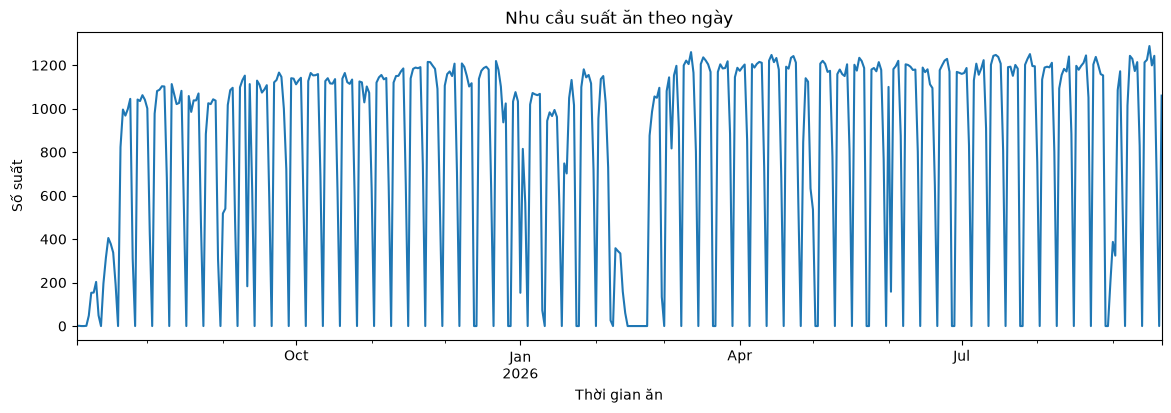

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Dùng vị trí cột vì tên tiếng Việt trong file đang bị lỗi mã hóa.
time_col = df.columns[10]
status_col = df.columns[11]
meal_time = pd.to_datetime(df[time_col], errors='coerce', dayfirst=False)
valid_status = df[status_col].astype('string').str.startswith('H')

# Nhu cầu suất ăn = số lượt hợp lệ theo từng ngày.
daily_demand = (
    meal_time[valid_status]
    .dt.floor('D')
    .value_counts()
    .sort_index()
    .rename('meal_count')
    .asfreq('D', fill_value=0)
)

print(f'Khoảng thời gian: {daily_demand.index.min().date()} đến {daily_demand.index.max().date()}')
print(f'Số ngày: {len(daily_demand)}, tổng lượt hợp lệ: {daily_demand.sum()}')
daily_demand.plot(figsize=(14, 4), title='Nhu cầu suất ăn theo ngày')
plt.ylabel('Số suất')
plt.show()

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

values = daily_demand.to_numpy(dtype='float32').reshape(-1, 1)
train_size = int(len(values) * 0.8)
scaler = MinMaxScaler()
scaler.fit(values[:train_size])
scaled_values = scaler.transform(values)

window_size = 14

def make_sequences(series, window):
    X, y = [], []
    for i in range(window, len(series)):
        X.append(series[i - window:i])
        y.append(series[i])
    return np.array(X), np.array(y)

X, y = make_sequences(scaled_values, window_size)
train_end = train_size - window_size
X_train, X_test = X[:train_end], X[train_end:]
y_train, y_test = y[:train_end], y[train_end:]

print('X_train:', X_train.shape, '| X_test:', X_test.shape)
print('Khoảng test:', daily_demand.index[train_size].date(), 'đến', daily_demand.index[-1].date())

c:\Users\cris\anaconda3\envs\hr-rag\Lib\site-packages\requests\__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


X_train: (342, 14, 1) | X_test: (90, 14, 1)
Khoảng test: 2026-06-24 đến 2026-09-21


In [6]:
model = Sequential([
    GRU(64, input_shape=(window_size, 1)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.1,
    shuffle=False,
    callbacks=[EarlyStopping(patience=12, restore_best_weights=True)],
    verbose=0
)

pred_scaled = model.predict(X_test, verbose=0)
pred = scaler.inverse_transform(pred_scaled).ravel()
actual = scaler.inverse_transform(y_test).ravel()
pred = np.maximum(pred, 0)

mae = mean_absolute_error(actual, pred)
rmse = np.sqrt(mean_squared_error(actual, pred))
print(f'MAE: {mae:.2f} suất')
print(f'RMSE: {rmse:.2f} suất')
print(f'Số epoch thực tế: {len(history.history["loss"])}')

c:\Users\cris\anaconda3\envs\hr-rag\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


MAE: 136.92 suất
RMSE: 232.75 suất
Số epoch thực tế: 47


Baseline 7 ngày - MAE: 375.18, RMSE: 470.37


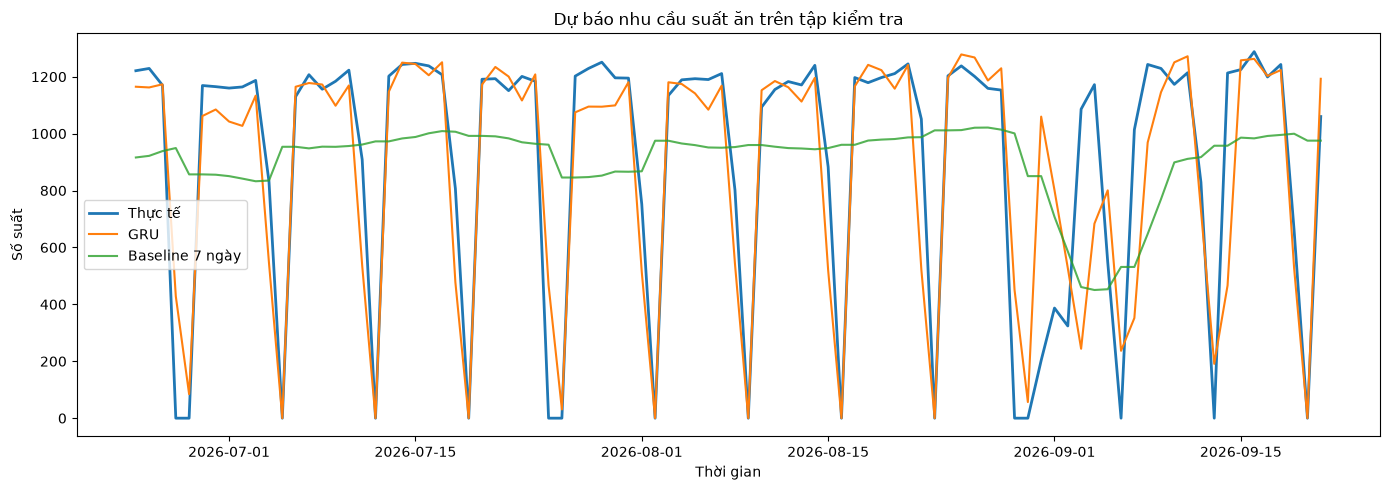

In [7]:
test_dates = daily_demand.index[train_size:]
baseline = np.array([
    values[i - 7:i].mean()
    for i in range(train_size, len(values))
]).ravel()

baseline_mae = mean_absolute_error(actual, baseline)
baseline_rmse = np.sqrt(mean_squared_error(actual, baseline))
print(f'Baseline 7 ngày - MAE: {baseline_mae:.2f}, RMSE: {baseline_rmse:.2f}')

plt.figure(figsize=(14, 5))
plt.plot(test_dates, actual, label='Thực tế', linewidth=2)
plt.plot(test_dates, pred, label='GRU', linewidth=1.5)
plt.plot(test_dates, baseline, label='Baseline 7 ngày', alpha=0.8)
plt.title('Dự báo nhu cầu suất ăn trên tập kiểm tra')
plt.xlabel('Thời gian')
plt.ylabel('Số suất')
plt.legend()
plt.tight_layout()
plt.show()